<a href="https://colab.research.google.com/github/aapaul29/Distance-Recognition-SML1-/blob/aaryan-workspace/main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **SML Project 1**

This notebook works in both **VS Code (local)** and **Google Colab**.

## **1. <u>Environment Detection & Setup</u>**

In [1]:
import sys
import os

IN_COLAB = 'google.colab' in sys.modules
print(f"Running in {'Google Colab' if IN_COLAB else 'VS Code / local'}")

Running in VS Code / local




## **2. <u>Google Colab: Mount Drive & Navigate to Project</u>**
This cell only runs on Colab. Adjust `COLAB_PROJECT_PATH` to where you uploaded the project folder in your Google Drive.

In [2]:
# ---------------------------------------------------------------
# COLAB ONLY — skip if running locally
# Adjust this path to match your Google Drive folder structure.
COLAB_PROJECT_PATH = "/content/drive/MyDrive/Aaryan/Uni/BS-Mech-Eng-ETH-Zurich/2nd-year/Semester-4/Stochastics&Machine-Learning/Distance-Recognition-SML1-"
# ---------------------------------------------------------------

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    %cd "$COLAB_PROJECT_PATH"
    print(f"Working directory: {os.getcwd()}")

    # Unzip data if not already extracted
    data_zip = os.path.join(COLAB_PROJECT_PATH, "data.zip")
    data_dir = os.path.join(COLAB_PROJECT_PATH, "data")
    if os.path.exists(data_zip) and not os.path.exists(data_dir):
        print("Unzipping data...")
        os.makedirs(data_dir, exist_ok=True)
        !unzip -q $data_zip -d $data_dir
        print("Done.")
    else:
        print("Data directory already exists or no zip found — skipping unzip.")
else:
    print("Local environment — no mounting needed.")

Local environment — no mounting needed.


## **3. <u>Auto-reload & Imports</u>**

In [3]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import uniform, randint

# Sklearn imports
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.ensemble import (
    HistGradientBoostingRegressor,
    ExtraTreesRegressor,
    StackingRegressor,
)
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, r2_score

# skimage intentionally NOT imported — HOG implemented manually with NumPy below

from utils import load_config, load_dataset, load_test_dataset, print_results, save_results

config = load_config()

[INFO]: Configs are loaded with: 
 {'data_dir': WindowsPath('data'), 'load_rgb': True, 'downsample_factor': 2}


In [4]:
if IN_COLAB:
    import shutil
    from pathlib import Path
    src = "/content/drive/MyDrive/Aaryan/Uni/BS-Mech-Eng-ETH-Zurich/2nd-year/Semester-4/Stochastics&Machine-Learning/Distance-Recognition-SML1-/data"
    dst = "/content/data"
    if not Path(dst).exists():
        print("Copying data to local Colab storage (faster I/O)...")
        shutil.copytree(src, dst)
        print("Done.")
    else:
        print("Local data already exists — skipping copy.")
    config["data_dir"] = Path(dst)
else:
    print("Running locally-copying not needed")

Running locally-copying not needed


## <u>**Feature Engineering**</u>

In [5]:
def extract_hog_features(images_flat, img_height, img_width, n_channels,
                          pixels_per_cell=(16, 16), cells_per_block=(2, 2),
                          orientations=9):
    """
    HOG feature extraction using NumPy only (no skimage).

    RGB images: gradients computed per channel; channel with highest magnitude
    wins at each pixel (standard multi-channel HOG behaviour).
    Block normalisation: L2-Hys (clip at 0.2, renormalise).
    """
    cy, cx  = pixels_per_cell
    by, bx  = cells_per_block
    ncy     = img_height // cy
    ncx     = img_width  // cx
    nby     = ncy - by + 1
    nbx     = ncx - bx + 1
    h_crop  = ncy * cy
    w_crop  = ncx * cx
    n_cells = ncy * ncx
    cell_px = cy * cx
    bw      = np.pi / orientations
    n_feat  = nby * nbx * by * bx * orientations

    result  = np.zeros((len(images_flat), n_feat), np.float32)

    # Precompute cell-pixel linear index (constant across all images)
    lin_idx = np.repeat(np.arange(n_cells), cell_px)  # (n_cells * cell_px,)

    for i, flat in enumerate(images_flat):
        # ── Compute gradients ────────────────────────────────────────────
        if n_channels > 1:
            img = flat.reshape(img_height, img_width, n_channels).astype(np.float32)
            gx  = np.zeros((img_height, img_width), np.float32)
            gy  = np.zeros((img_height, img_width), np.float32)
            mag = np.zeros((img_height, img_width), np.float32)
            for c in range(n_channels):
                ch   = img[:, :, c]
                gxc  = np.empty_like(ch)
                gyc  = np.empty_like(ch)
                gxc[:, 1:-1] = ch[:, 2:]  - ch[:, :-2]
                gxc[:, 0]    = ch[:, 1]   - ch[:, 0]
                gxc[:, -1]   = ch[:, -1]  - ch[:, -2]
                gyc[1:-1, :] = ch[2:, :]  - ch[:-2, :]
                gyc[0, :]    = ch[1, :]   - ch[0, :]
                gyc[-1, :]   = ch[-1, :]  - ch[-2, :]
                mc = np.sqrt(gxc * gxc + gyc * gyc)
                better = mc > mag
                gx[better]  = gxc[better]
                gy[better]  = gyc[better]
                mag[better] = mc[better]
        else:
            img = flat.reshape(img_height, img_width).astype(np.float32)
            gx  = np.empty_like(img)
            gy  = np.empty_like(img)
            gx[:, 1:-1] = img[:, 2:]  - img[:, :-2]
            gx[:, 0]    = img[:, 1]   - img[:, 0]
            gx[:, -1]   = img[:, -1]  - img[:, -2]
            gy[1:-1, :] = img[2:, :]  - img[:-2, :]
            gy[0, :]    = img[1, :]   - img[0, :]
            gy[-1, :]   = img[-1, :]  - img[-2, :]
            mag = np.sqrt(gx * gx + gy * gy)

        # ── Unsigned orientation [0, π) with bilinear bin interpolation ──
        angle  = np.arctan2(gy, gx) % np.pi          # [0, π)
        bidx   = angle / bw                           # [0, orientations)
        blo    = np.floor(bidx).astype(np.int32) % orientations
        bhi    = (blo + 1) % orientations
        w_hi   = (bidx - np.floor(bidx)).astype(np.float32)
        w_lo   = 1.0 - w_hi

        # ── Reshape into (n_cells, cell_px) via (ncy, cy, ncx, cx) ──────
        def to_cells(arr):
            return (arr[:h_crop, :w_crop]
                       .reshape(ncy, cy, ncx, cx)
                       .transpose(0, 2, 1, 3)
                       .reshape(n_cells, cell_px))

        mag_c = to_cells(mag)
        blo_c = to_cells(blo)
        bhi_c = to_cells(bhi)
        wlo_c = to_cells(w_lo)
        whi_c = to_cells(w_hi)

        # ── Vectorised cell histograms via linear-index accumulation ─────
        lin_lo  = lin_idx * orientations + blo_c.ravel()
        lin_hi  = lin_idx * orientations + bhi_c.ravel()
        ch_flat = np.zeros(n_cells * orientations, np.float32)
        np.add.at(ch_flat, lin_lo, (mag_c * wlo_c).ravel())
        np.add.at(ch_flat, lin_hi, (mag_c * whi_c).ravel())
        cell_hists = ch_flat.reshape(ncy, ncx, orientations)

        # ── Block normalisation (L2-Hys) ─────────────────────────────────
        blocks = []
        for r in range(nby):
            for c_i in range(nbx):
                blk  = cell_hists[r:r+by, c_i:c_i+bx].ravel().copy()
                blk /= np.sqrt(np.dot(blk, blk) + 1e-6)
                np.clip(blk, 0.0, 0.2, out=blk)
                blk /= np.sqrt(np.dot(blk, blk) + 1e-6)
                blocks.append(blk)

        result[i] = np.concatenate(blocks)

    return result

In [6]:
def extract_spatial_features(images_flat, img_height, img_width, n_channels):
    """
    Extract spatial statistics per image quadrant.
    Divides image into 4 quadrants and computes mean, std, min, max per quadrant.
    """
    features = []
    for i in range(len(images_flat)):
        img = images_flat[i].reshape(img_height, img_width, n_channels) if n_channels > 1 \
              else images_flat[i].reshape(img_height, img_width)

        mid_h = img_height // 2
        mid_w = img_width // 2

        quadrants = [
            img[:mid_h, :mid_w],
            img[:mid_h, mid_w:],
            img[mid_h:, :mid_w],
            img[mid_h:, mid_w:],
        ]

        row = []
        for q in quadrants:
            row.extend([q.mean(), q.std(), q.min(), q.max()])

        row.extend([img.mean(), img.std(), img.min(), img.max()])
        row.append(np.var(images_flat[i]))

        features.append(row)

    return np.array(features)

In [12]:
def extract_color_histogram_features(images_flat, img_height, img_width, n_channels, bins=32):
    """
    Per-channel normalized color histograms. Color distribution shifts with
    distance due to lighting/perspective, making this a useful depth cue.
    """
    features = []
    for img_row in images_flat:
        img = img_row.reshape(img_height, img_width, n_channels) if n_channels > 1 \
              else img_row.reshape(img_height, img_width, 1)
        row = []
        for c in range(n_channels):
            hist, _ = np.histogram(img[:, :, c], bins=bins, range=(0, 256))
            row.extend(hist / (hist.sum() + 1e-8))
        features.append(row)
    return np.array(features)

In [13]:
def build_features(images_flat, config):
    """
    Combine raw pixels + HOG + spatial statistics + per-channel color histograms.
    """
    IMAGE_SIZE = (300, 300)
    img_height = IMAGE_SIZE[0] // config["downsample_factor"]
    img_width  = IMAGE_SIZE[1] // config["downsample_factor"]
    n_channels = 3 if config["load_rgb"] else 1

    print(f"[INFO]: Image dimensions: {img_height}x{img_width}x{n_channels}")
    print(f"[INFO]: Raw pixel features: {images_flat.shape[1]}")

    print("[INFO]: Extracting HOG features...")
    t0 = time.time()
    hog_feats = extract_hog_features(images_flat, img_height, img_width, n_channels)
    print(f"[INFO]: HOG features: {hog_feats.shape[1]} (took {time.time()-t0:.1f}s)")

    print("[INFO]: Extracting spatial statistics...")
    spatial_feats = extract_spatial_features(images_flat, img_height, img_width, n_channels)
    print(f"[INFO]: Spatial features: {spatial_feats.shape[1]}")

    print("[INFO]: Extracting color histograms...")
    color_feats = extract_color_histogram_features(images_flat, img_height, img_width, n_channels, bins=32)
    print(f"[INFO]: Color histogram features: {color_feats.shape[1]}")

    combined = np.hstack([images_flat, hog_feats, spatial_feats, color_feats])
    print(f"[INFO]: Combined features: {combined.shape[1]}")

    return combined

In [14]:
images, distances = load_dataset(config, split="train")
print(f"[INFO]: Dataset loaded with {len(images)} samples.")
print(f"[INFO]: Feature dimensionality: {images.shape[1]}")
print(f"Images shape : {images.shape}")
print(f"Distances shape: {distances.shape}")
print(f"Distance range : {distances.min():.2f} m – {distances.max():.2f} m")

[INFO]: Dataset loaded with 3000 samples.
[INFO]: Feature dimensionality: 67500
Images shape : (3000, 67500)
Distances shape: (3000,)
Distance range : 0.25 m – 2.78 m


In [15]:
# ── Feature Engineering ──────────────────────────────────────────────────
print("\n" + "="*60)
print("  FEATURE ENGINEERING")
print("="*60)
X_all = build_features(images, config)


  FEATURE ENGINEERING
[INFO]: Image dimensions: 150x150x3
[INFO]: Raw pixel features: 67500
[INFO]: Extracting HOG features...
[INFO]: HOG features: 2304 (took 15.4s)
[INFO]: Extracting spatial statistics...
[INFO]: Spatial features: 21
[INFO]: Extracting color histograms...
[INFO]: Color histogram features: 96
[INFO]: Combined features: 69921


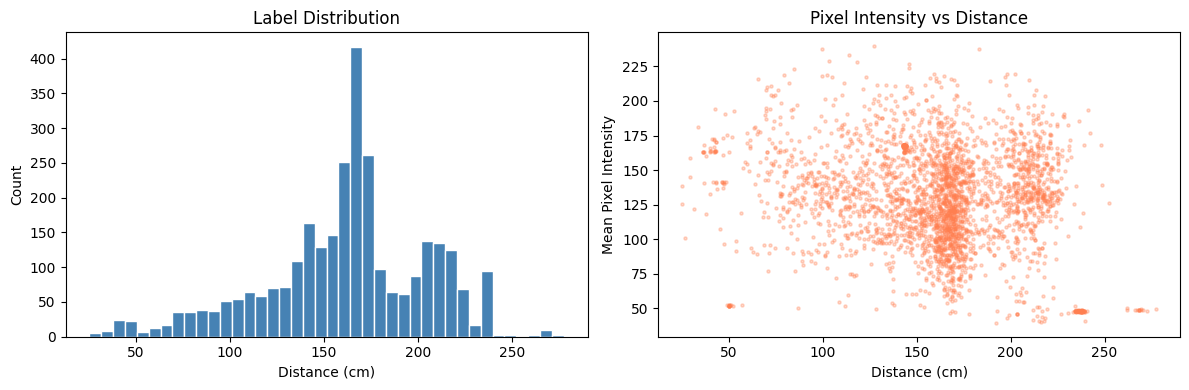

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Label distribution
axes[0].hist(distances * 100, bins=40, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Distance (cm)')
axes[0].set_ylabel('Count')
axes[0].set_title('Label Distribution')

# Mean pixel intensity vs distance
mean_intensity = images.mean(axis=1)
axes[1].scatter(distances * 100, mean_intensity, alpha=0.3, s=5, color='coral')
axes[1].set_xlabel('Distance (cm)')
axes[1].set_ylabel('Mean Pixel Intensity')
axes[1].set_title('Pixel Intensity vs Distance')

plt.tight_layout()
plt.show()

## **4. <u>ML Model Implementation</u>**
Implement preprocessing, model training, data split and evaluation.

**4.1. <u>Creating Splits</u>**

train (70%) | val (15%) | test (15%)

Why three splits?
* train  → the model learns from this
* val    → we tune hyperparameters on this (never used for fitting)
* test   → final local evaluation; simulates the private Kaggle set
* random_state=42 keeps the split identical every run (reproducibility)

**FIX**: Splits are now applied to `X_all` (engineered features), not raw `images`.

In [17]:
# Split on X_all (engineered features), not raw images
# First split off the test set (15%)
X_trainval, X_test, y_trainval, y_test = train_test_split(
        X_all, distances,
        test_size=0.15,
        random_state=42)

# Then split the remaining 85% into train (~70%) and val (~15%)
# 0.15 / 0.85 ≈ 0.176 → gives ~15% of total as validation
X_train, X_val, y_train, y_val = train_test_split(
        X_trainval, y_trainval,
        test_size=0.176,
        random_state=42)

print(f"[INFO]: Split sizes — train: {len(X_train)}, "
      f"val: {len(X_val)}, test: {len(X_test)}")

[INFO]: Split sizes — train: 2101, val: 449, test: 450


In [18]:
# ── Preprocessing ─────────────────────────────────────────────────────────
# Strategy: scale all features, then let each model handle dimensionality:
#   • HGBR / ExtraTrees  → trained directly on scaled features (handles high-dim natively)
#   • KNN                → wrapped in a Pipeline that applies PCA first

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit + transform on train only
X_val_scaled   = scaler.transform(X_val)          # transform only
X_test_scaled  = scaler.transform(X_test)         # transform only

print(f"[INFO]: Scaling done. Feature shape: {X_train_scaled.shape}")
print(f"        Mean (train, first 5): {X_train_scaled.mean(axis=0)[:5].round(4)}")
print(f"        Std  (train, first 5): {X_train_scaled.std(axis=0)[:5].round(4)}")

[INFO]: Scaling done. Feature shape: (2101, 69921)
        Mean (train, first 5): [ 0. -0.  0. -0. -0.]
        Std  (train, first 5): [1. 1. 1. 1. 1.]


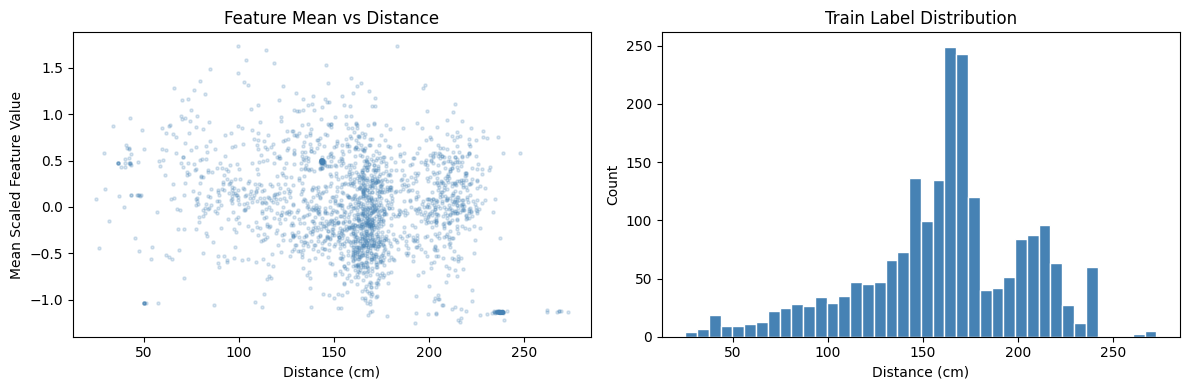

[INFO]: Training on 69921 features per sample.


In [19]:
# Quick depth-cue sanity check: mean pixel intensity vs distance
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

mean_intensity = X_train_scaled.mean(axis=1)
axes[0].scatter(y_train * 100, mean_intensity, alpha=0.2, s=5, color='steelblue')
axes[0].set_xlabel('Distance (cm)')
axes[0].set_ylabel('Mean Scaled Feature Value')
axes[0].set_title('Feature Mean vs Distance')

axes[1].hist(y_train * 100, bins=40, color='steelblue', edgecolor='white')
axes[1].set_xlabel('Distance (cm)')
axes[1].set_ylabel('Count')
axes[1].set_title('Train Label Distribution')

plt.tight_layout()
plt.show()
print(f"[INFO]: Training on {X_train_scaled.shape[1]} features per sample.")

In [20]:
# ── Ridge Regression (baseline, uses PCA pipeline like KNN) ──────────────
ridge_pipe = Pipeline([
    ('pca', PCA(n_components=200, random_state=42)),
    ('ridge', Ridge(alpha=1.0)),
])
ridge_pipe.fit(X_train_scaled, y_train)
val_pred_ridge = ridge_pipe.predict(X_val_scaled)
mae_ridge = mean_absolute_error(y_val, val_pred_ridge) * 100
print(f"Ridge (PCA+Ridge) — Val MAE: {mae_ridge:.2f} cm")

Ridge (PCA+Ridge) — Val MAE: 22.20 cm


In [21]:
# ── HGBR with good fixed params (trains on raw scaled features — no PCA needed) ──
hgbr = HistGradientBoostingRegressor(
    learning_rate=0.05,
    max_iter=800,
    max_depth=8,
    min_samples_leaf=10,
    l2_regularization=0.1,
    max_leaf_nodes=63,
    random_state=42,
)
hgbr.fit(X_train_scaled, y_train)
val_pred_hgbr = hgbr.predict(X_val_scaled)
mae_hgbr = mean_absolute_error(y_val, val_pred_hgbr) * 100
r2_hgbr  = r2_score(y_val, val_pred_hgbr) * 100
print(f"HGBR (fixed params) — Val MAE: {mae_hgbr:.2f} cm  |  R²: {r2_hgbr:.1f}%")

KeyboardInterrupt: 

In [ ]:
# ── ExtraTreesRegressor (trains on raw scaled features) ──────────────────
etr = ExtraTreesRegressor(
    n_estimators=400,
    max_depth=None,
    min_samples_leaf=3,
    n_jobs=-1,
    random_state=42,
)
etr.fit(X_train_scaled, y_train)
val_pred_etr = etr.predict(X_val_scaled)
mae_etr = mean_absolute_error(y_val, val_pred_etr) * 100
r2_etr  = r2_score(y_val, val_pred_etr) * 100
print(f"ExtraTrees — Val MAE: {mae_etr:.2f} cm  |  R²: {r2_etr:.1f}%")

In [ ]:
# ── KNN wrapped in Pipeline(PCA → KNN) ────────────────────────────────────
# KNN needs low-dimensional input due to curse of dimensionality, so we apply
# PCA inside the pipeline. This way the stacking ensemble can pass scaled
# features uniformly to all base learners.
print("[INFO]: Tuning KNN (PCA + KNeighbors pipeline)...")

N_PCA_KNN = 200
best_knn_mae = float('inf')
best_k        = 5
best_weights  = 'distance'

for k in [3, 5, 7, 9, 11, 15, 20]:
    for w in ['uniform', 'distance']:
        pipe = Pipeline([
            ('pca', PCA(n_components=N_PCA_KNN, random_state=42)),
            ('knn', KNeighborsRegressor(n_neighbors=k, weights=w, n_jobs=-1)),
        ])
        pipe.fit(X_train_scaled, y_train)
        mae = mean_absolute_error(y_val, pipe.predict(X_val_scaled)) * 100
        if mae < best_knn_mae:
            best_knn_mae = mae
            best_k       = k
            best_weights = w

print(f"Best KNN params: k={best_k}, weights='{best_weights}'")

best_knn_pipe = Pipeline([
    ('pca', PCA(n_components=N_PCA_KNN, random_state=42)),
    ('knn', KNeighborsRegressor(n_neighbors=best_k, weights=best_weights, n_jobs=-1)),
])
best_knn_pipe.fit(X_train_scaled, y_train)
val_pred_knn = best_knn_pipe.predict(X_val_scaled)
mae_knn = mean_absolute_error(y_val, val_pred_knn) * 100
r2_knn  = r2_score(y_val, val_pred_knn) * 100
print(f"KNN (k={best_k}, {best_weights}) — Val MAE: {mae_knn:.2f} cm  |  R²: {r2_knn:.1f}%")

In [ ]:
# ── MLP excluded from ensemble ────────────────────────────────────────────
# MLPRegressor previously scored -72.9% R² (43 cm MAE) on this data,
# which is worse than predicting the mean. Including a broken learner in
# the stacking ensemble forces the meta-learner to compensate for noise.
# Excluded to keep the ensemble clean.
print("[INFO]: MLP excluded from ensemble (unstable on this dataset).")

In [ ]:
# ── RandomizedSearchCV for HGBR (100 iterations, trains on scaled features) ──
print("[INFO]: Running RandomizedSearchCV for HGBR (100 iter × 5-fold = 500 fits)...")

param_dist = {
    'learning_rate':     uniform(0.02, 0.13),    # 0.02 – 0.15
    'max_depth':         randint(5, 13),          # 5 – 12
    'max_iter':          randint(500, 2000),      # 500 – 2000
    'min_samples_leaf':  randint(5, 30),          # 5 – 30
    'l2_regularization': uniform(0.0, 0.5),       # 0 – 0.5
    'max_leaf_nodes':    randint(31, 128),        # 31 – 127
}

random_search = RandomizedSearchCV(
    HistGradientBoostingRegressor(random_state=42),
    param_dist,
    n_iter=100,
    scoring='neg_mean_absolute_error',
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1,
)
random_search.fit(X_train_scaled, y_train)

best_hgbr = random_search.best_estimator_
print(f"Best HGBR params: {random_search.best_params_}")

val_pred_best = best_hgbr.predict(X_val_scaled)
mae_best = mean_absolute_error(y_val, val_pred_best) * 100
r2_best  = r2_score(y_val, val_pred_best) * 100
print(f"HGBR (tuned) — Val MAE: {mae_best:.2f} cm  |  R²: {r2_best:.1f}%")

In [ ]:
# ── Stacking Ensemble ─────────────────────────────────────────────────────
# Base learners: HGBR (tuned) + ExtraTrees + KNN-in-pipeline
# Meta-learner: HGBR (light) — better than Ridge for non-linear meta-learning
# MLP removed: was getting -72.9% R², only added noise
print("[INFO]: Training stacking ensemble...")

stack_estimators = [
    ('hgbr', best_hgbr),
    ('etr', ExtraTreesRegressor(
        n_estimators=300, max_depth=None, min_samples_leaf=3,
        n_jobs=-1, random_state=42)),
    ('knn', Pipeline([
        ('pca', PCA(n_components=200, random_state=42)),
        ('knn', KNeighborsRegressor(n_neighbors=best_k, weights=best_weights, n_jobs=-1)),
    ])),
]

stack = StackingRegressor(
    estimators=stack_estimators,
    final_estimator=HistGradientBoostingRegressor(
        max_iter=200, learning_rate=0.05, max_depth=5, random_state=42),
    cv=5,
    n_jobs=-1,
)

stack.fit(X_train_scaled, y_train)
val_pred_stack = stack.predict(X_val_scaled)
mae_stack = mean_absolute_error(y_val, val_pred_stack) * 100
r2_stack  = r2_score(y_val, val_pred_stack) * 100
print(f"Stacking — Val MAE: {mae_stack:.2f} cm  |  R²: {r2_stack:.1f}%")

In [ ]:
# ── Model Comparison ─────────────────────────────────────────────────────
results = {
    'Ridge (baseline)':    mae_ridge,
    'HGBR (fixed params)': mae_hgbr,
    'HGBR (tuned)':        mae_best,
    'ExtraTrees':          mae_etr,
    f'KNN (k={best_k})':   mae_knn,
    'Stacking':            mae_stack,
}

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#aac4e0'] * len(results)
bars = ax.barh(list(results.keys()), list(results.values()), color=colors)
ax.axvline(28, color='orange', linestyle='--', label='Grade 1.0 (28 cm)')
ax.axvline(18, color='gold',   linestyle='--', label='Grade 4.0 (18 cm)')
ax.axvline(8,  color='green',  linestyle='--', label='Grade 6.0 (8 cm)')
ax.set_xlabel('Val MAE (cm)')
ax.set_title('Model Comparison on Validation Set')
ax.legend()
for bar, val in zip(bars, results.values()):
    ax.text(val + 0.3, bar.get_y() + bar.get_height()/2, f'{val:.1f} cm', va='center')
plt.tight_layout()
plt.show()

In [ ]:
# ── Pick final model + evaluate on held-out test set ─────────────────────
# Use whichever had the lowest val MAE
final_model = stack   # swap to best_hgbr if stacking is slower to retrain

test_pred = final_model.predict(X_test_scaled)
print("=== FINAL TEST SET RESULTS ===")
print_results(y_test, test_pred)

In [ ]:
# ── Retrain on FULL labelled dataset + generate Kaggle submission ─────────
X_all_scaled = scaler.fit_transform(X_all)   # refit scaler on all labelled data

final_model.fit(X_all_scaled, distances)
print("Final model retrained on full labelled dataset")

# ── Load, engineer features, and transform Kaggle test images ────────────
kaggle_images_raw = load_test_dataset(config)
kaggle_images_raw = np.array(kaggle_images_raw)

kaggle_features = build_features(kaggle_images_raw, config)
kaggle_scaled   = scaler.transform(kaggle_features)   # transform only, never refit

kaggle_pred = final_model.predict(kaggle_scaled)

save_results(kaggle_pred)
print(f"Saved prediction.csv with {len(kaggle_pred)} predictions")
print(f"Predicted distance range: {kaggle_pred.min():.2f} m – {kaggle_pred.max():.2f} m")

In [ ]:
# ── Retrain on FULL labelled dataset + generate Kaggle submission ─────────
# FIX 1: refit on X_all (engineered features), not raw images
# FIX 2: use random_search.best_params_ (not grid_search — which didn't exist)

X_all_scaled = scaler.fit_transform(X_all)        # refit on all labelled data
X_all_pca    = pca.fit_transform(X_all_scaled)    # refit on all labelled data

final_model.fit(X_all_pca, distances)
print("Final model retrained on full labelled dataset")

# ── Load and transform Kaggle test images ────────────────────────────────
# FIX 3: apply build_features to kaggle test images too
kaggle_images_raw = load_test_dataset(config)
kaggle_images_raw = np.array(kaggle_images_raw)

kaggle_features = build_features(kaggle_images_raw, config)
kaggle_scaled   = scaler.transform(kaggle_features)   # transform only, never fit
kaggle_pca      = pca.transform(kaggle_scaled)

kaggle_pred = final_model.predict(kaggle_pca)

save_results(kaggle_pred)
print(f"Saved prediction.csv with {len(kaggle_pred)} predictions")
print(f"Predicted distance range: {kaggle_pred.min():.2f} m – {kaggle_pred.max():.2f} m")

KeyboardInterrupt: 